In [1]:
!pip install tensorflow-metal

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
T = 200  # keep small for MNIST training speed

beta = tf.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = tf.math.cumprod(alpha)

In [3]:
def extract(a, t, x_shape):
    batch_size = tf.shape(t)[0]
    out = tf.gather(a, t)
    return tf.reshape(out, [batch_size] + [1] * (len(x_shape) - 1))

In [4]:
def q_sample(x0, t, noise):
    sqrt_alpha_bar = tf.sqrt(extract(alpha_bar, t, tf.shape(x0)))
    sqrt_one_minus = tf.sqrt(1 - extract(alpha_bar, t, tf.shape(x0)))

    return sqrt_alpha_bar * x0 + sqrt_one_minus * noise

In [5]:
class TimeEmbedding(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def call(self, t):
        half = self.dim // 2

        freqs = tf.exp(
            tf.linspace(0.0, -np.log(10000.0), half)
        )

        t = tf.cast(t, tf.float32)
        args = t[:, None] * freqs[None, :]

        return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

In [6]:
class ConvBlock(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()

        self.conv1 = tf.keras.layers.Conv2D(channels, 3, padding="same")
        self.norm1 = tf.keras.layers.GroupNormalization(groups=8)
        self.act1 = tf.keras.layers.Activation("swish")

        self.conv2 = tf.keras.layers.Conv2D(channels, 3, padding="same")
        self.norm2 = tf.keras.layers.GroupNormalization(groups=8)
        self.act2 = tf.keras.layers.Activation("swish")

        self.film1 = FiLM(channels)
        self.film2 = FiLM(channels)

    def call(self, x, t_emb):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.film1(x, t_emb)

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.act2(x)
        x = self.film2(x, t_emb)

        return x

In [7]:
class FiLM(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.to_gamma = tf.keras.layers.Dense(channels)
        self.to_beta = tf.keras.layers.Dense(channels)

    def call(self, x, t_emb):
        gamma = self.to_gamma(t_emb)
        beta = self.to_beta(t_emb)

        gamma = tf.reshape(gamma, [-1, 1, 1, tf.shape(x)[-1]])
        beta = tf.reshape(beta, [-1, 1, 1, tf.shape(x)[-1]])

        return x * (1.0 + gamma) + beta

In [8]:
class UNet(tf.keras.Model):
    def __init__(self, time_dim=128):
        super().__init__()

        self.time_embed = TimeEmbedding(time_dim)
        self.time_mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(time_dim, activation="swish"),
            tf.keras.layers.Dense(time_dim),
        ])

        # encoder
        self.down1 = ConvBlock(32)
        self.down2 = ConvBlock(64)

        # bottleneck
        self.mid = ConvBlock(64)

        # decoder
        self.up1 = ConvBlock(64)
        self.up2 = ConvBlock(32)

        self.pool = tf.keras.layers.MaxPool2D(2)
        self.up = tf.keras.layers.UpSampling2D(2)

        self.final = tf.keras.layers.Conv2D(1, 1)

    def call(self, x, t):
        # time embedding
        t_emb = self.time_embed(t)
        t_emb = self.time_mlp(t_emb)

        # encoder
        x1 = self.down1(x, t_emb)
        x2 = self.down2(self.pool(x1), t_emb)

        # bottleneck
        mid = self.mid(self.pool(x2), t_emb)

        # decoder
        u2 = self.up(mid)
        u2 = tf.concat([u2, x2], axis=-1)
        u2 = self.up1(u2, t_emb)

        u1 = self.up(u2)
        u1 = tf.concat([u1, x1], axis=-1)
        u1 = self.up2(u1, t_emb)

        return self.final(u1)

In [9]:
optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(model, x0):
    batch_size = tf.shape(x0)[0]

    t = tf.random.uniform((batch_size,), 0, T, dtype=tf.int32)
    noise = tf.random.normal(tf.shape(x0))

    x_noisy = q_sample(x0, t, noise)

    with tf.GradientTape() as tape:
        noise_pred = model(x_noisy, t)
        loss = tf.reduce_mean((noise - noise_pred) ** 2)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss

In [10]:
(x_train, _), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train * 2.0 - 1.0  # scale to [-1, 1]
x_train = np.expand_dims(x_train, -1)

train_ds = tf.data.Dataset.from_tensor_slices(x_train)
train_ds = train_ds.shuffle(60000).batch(128)

In [11]:
model = UNet()
epochs = 1
for epoch in range(epochs):
    bar = tf.keras.utils.Progbar(len(train_ds)-1)

    for step, batch in enumerate(train_ds):
        loss = train_step(model, batch)
        bar.update(step, values=[("loss", loss)])

    print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

468/468 ━━━━━━━━━━━━━━━━━━━━ 133s 276ms/step - loss: 0.1539
Epoch 0, Loss: 0.1539


In [12]:
def sample(model, n=16):
    x = tf.random.normal((n, 28, 28, 1))

    for t in reversed(range(T)):
        t_batch = tf.fill([n], t)

        noise_pred = model(x, t_batch)

        beta_t = beta[t]
        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]

        x = (1 / tf.sqrt(alpha_t)) * (
            x - (beta_t / tf.sqrt(1 - alpha_bar_t)) * noise_pred
        )

        if t > 0:
            x += tf.sqrt(beta_t) * tf.random.normal(tf.shape(x))

    return x

In [13]:
def sample_step(model, x, t):
    t_batch = tf.fill([1], t)

    noise_pred = model(x, t_batch)

    beta_t = beta[t]
    alpha_t = alpha[t]
    alpha_bar_t = alpha_bar[t]

    x = (1 / tf.sqrt(alpha_t)) * (
        x - (beta_t / tf.sqrt(1 - alpha_bar_t)) * noise_pred
    )

    if t > 0:
        x += tf.sqrt(beta_t) * tf.random.normal(tf.shape(x))

    return x

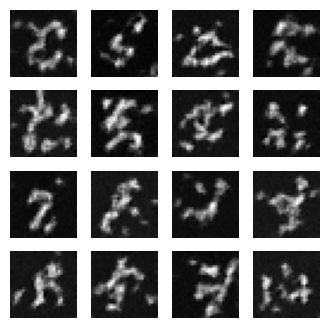

In [14]:
imgs = sample(model, 16)

imgs = (imgs + 1) / 2.0  # back to [0,1]

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(tf.squeeze(imgs[i]), cmap="gray")
    plt.axis("off")

plt.show()

In [15]:
# Save a GIF using logged images
def save_gif(img_list, path="", interval=200):
    # Transform images from [-1,1] to [0, 255]
    imgs = []
    for im in img_list:
        im = np.array(im)
        im = (im + 1) / 2.0
        im = np.clip(im, 0, 255).astype(np.int32)
        im = Image.fromarray(im)
        imgs.append(im)
    
    imgs = iter(imgs)

    # Extract first image from iterator
    img = next(imgs)

    # Append the other images and save as GIF
    img.save(fp=path, format='GIF', append_images=imgs,
             save_all=True, duration=interval, loop=0)

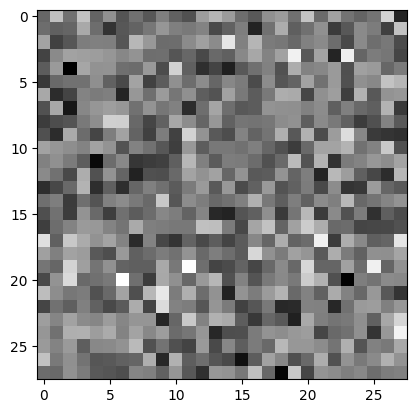

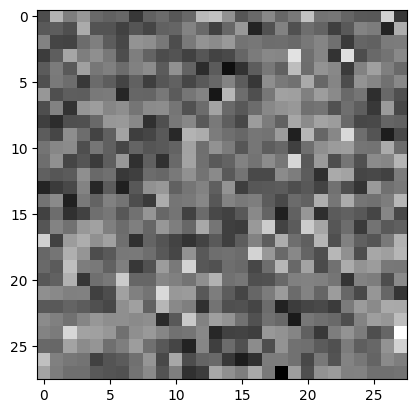

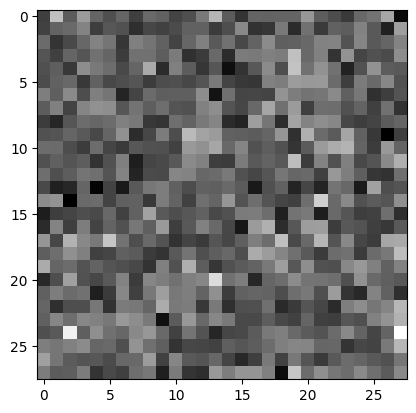

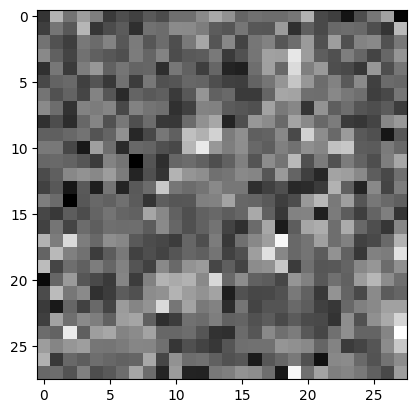

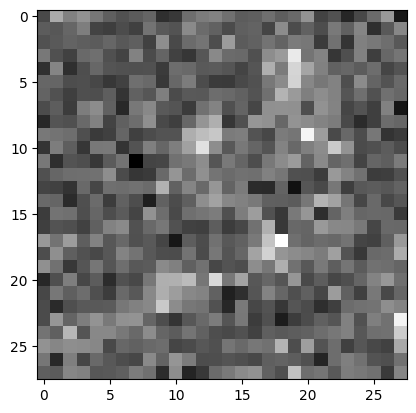

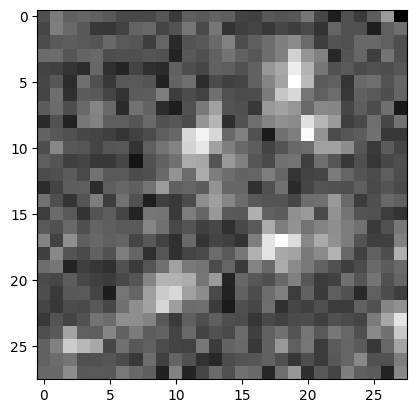

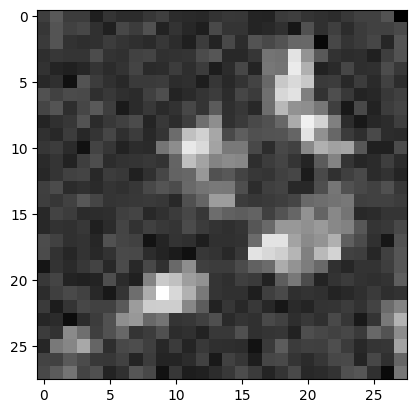

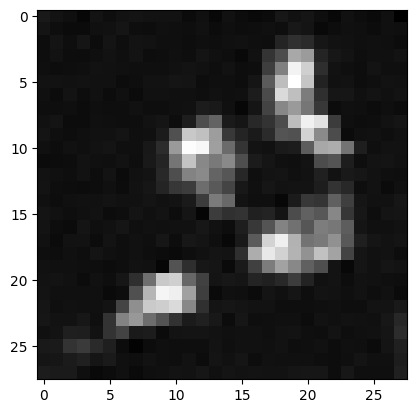

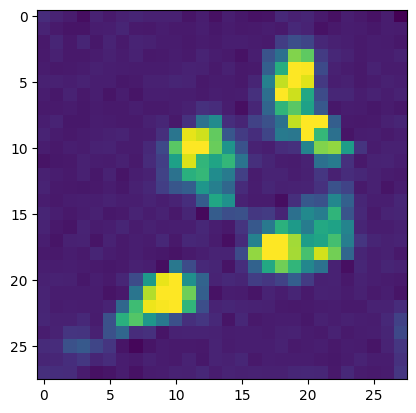

In [26]:
x = tf.random.normal((1,28,28,1))
img_list = []
img_list.append(tf.squeeze((x+1)*127.5))

for t in reversed(range(T)):
    x = sample_step(model, x, t)
    img_list.append(tf.squeeze((x+1)*127.5))

    if t % 25==0:
        plt.imshow(tf.squeeze((x+1)*127.5), cmap="gray")
        plt.show()

save_gif(img_list + ([img_list[-1]] * 100), f"ddpm_gpt_{epochs}.gif", interval=20)

plt.imshow(np.array(np.clip((x[0] + 1) * 127.5, 0, 255), np.uint8))
plt.show()

In [25]:
T

200